In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

<h4>adding this function for reproducibility</h4>

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
dataset = load_dataset("scikit-learn/adult-census-income")


In [ ]:
dataset['train']

Dataset({
    features: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income'],
    num_rows: 32561
})

In [ ]:
dataset = load_dataset("scikit-learn/adult-census-income")
df = dataset['train'].to_pandas()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


<h4> Visualization of Categorical features</h4>

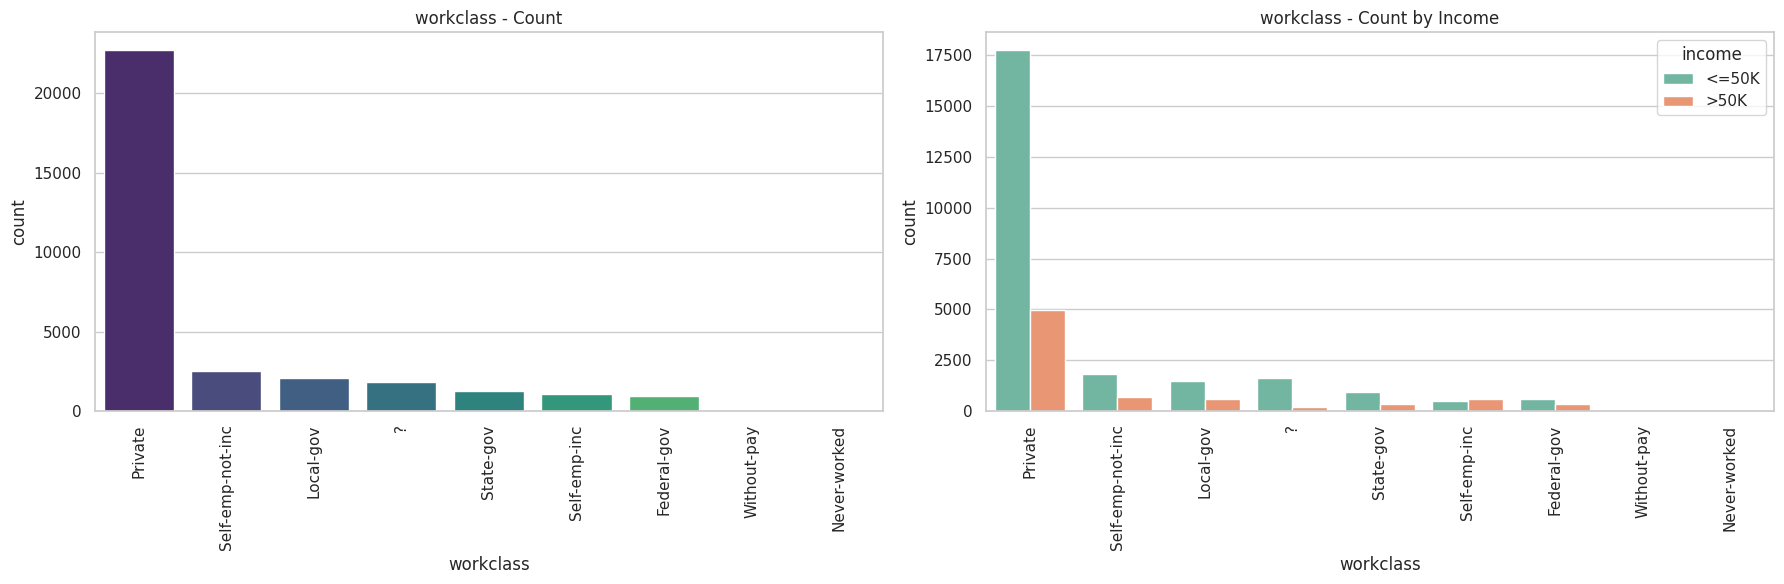

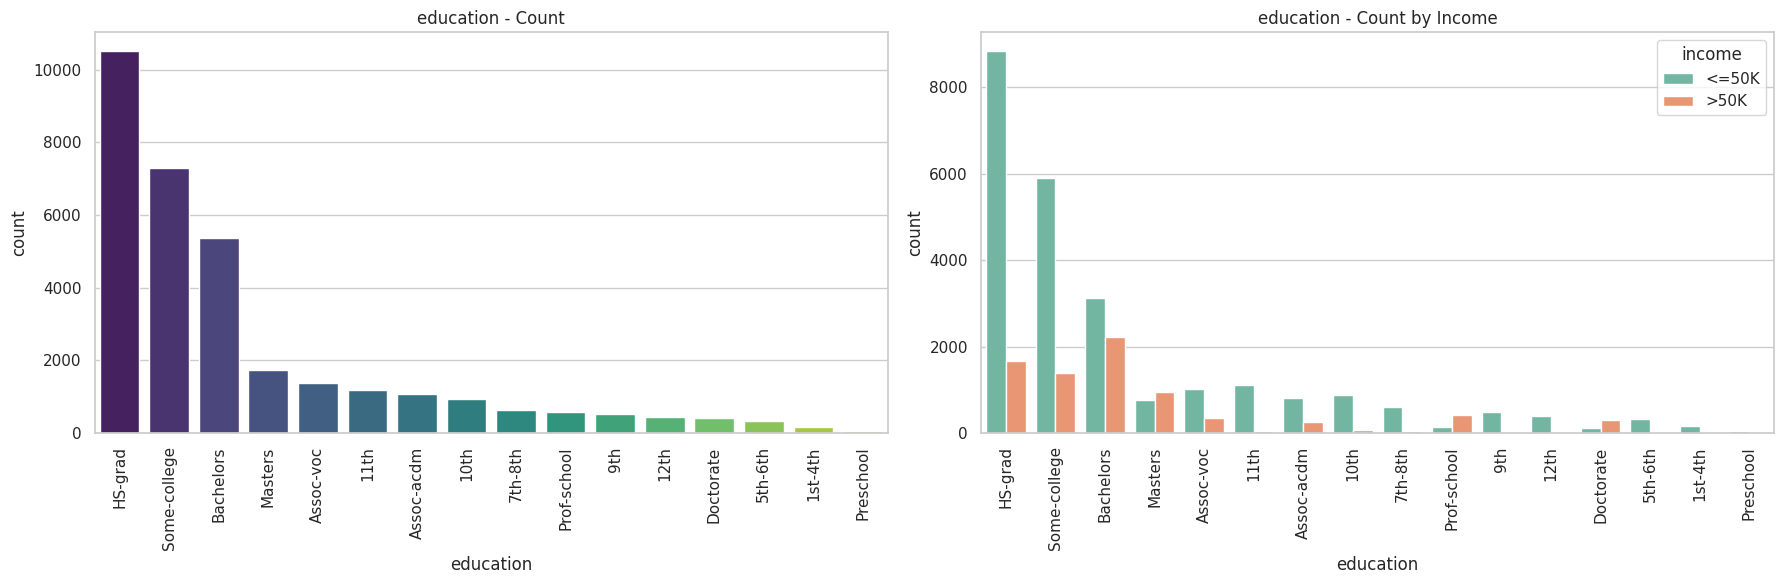

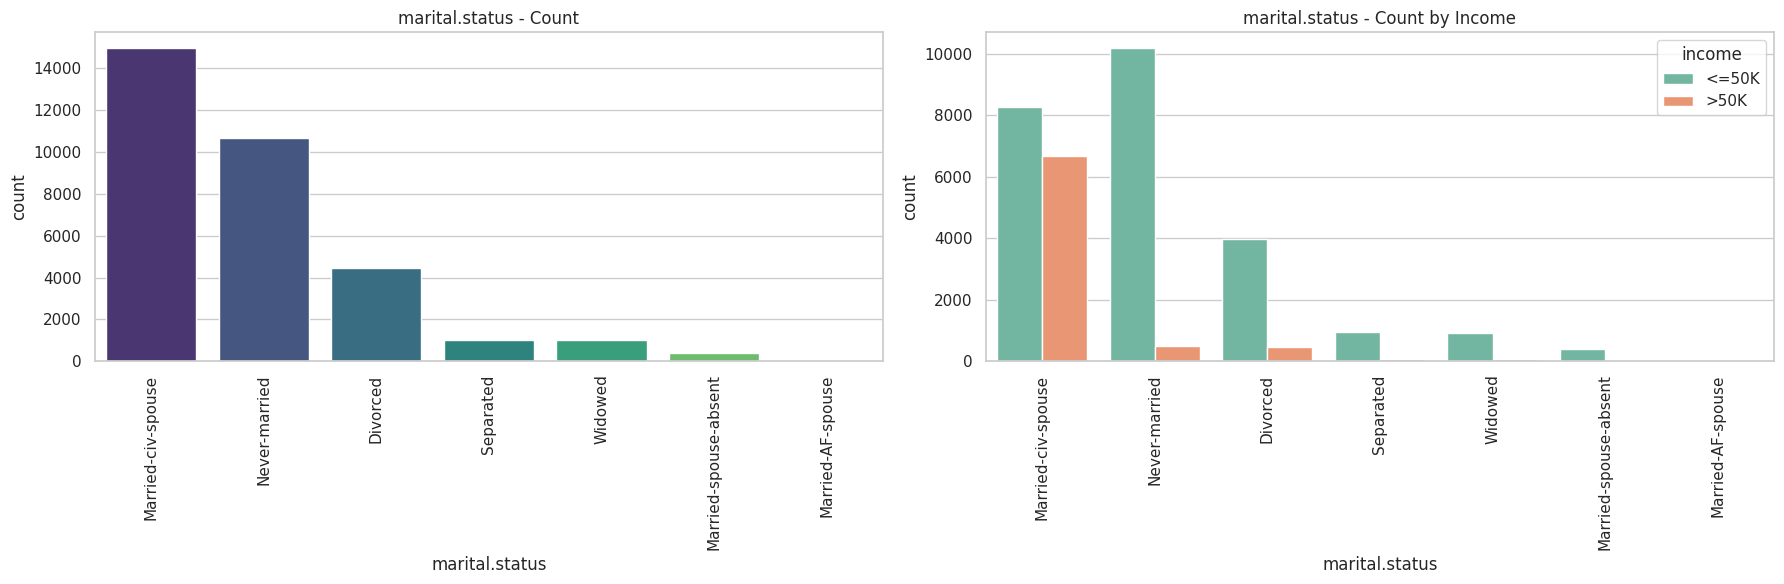

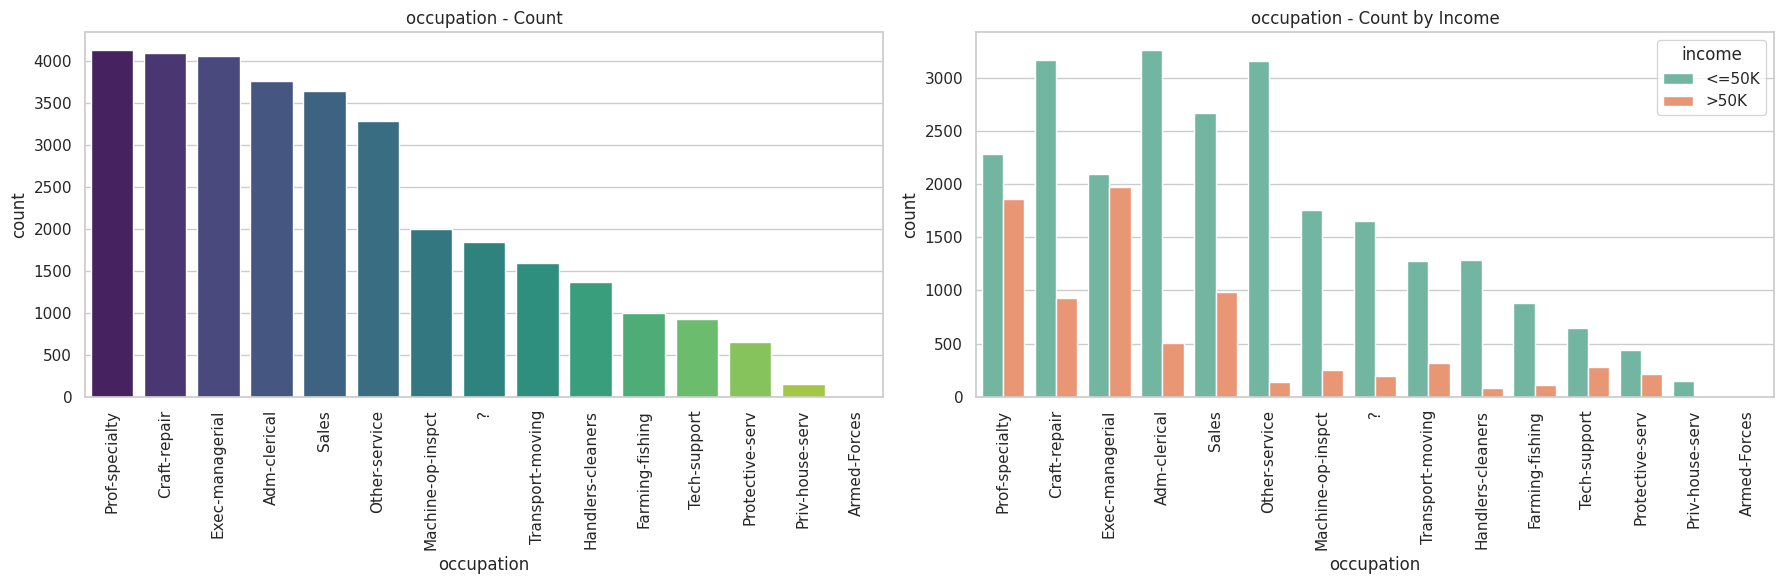

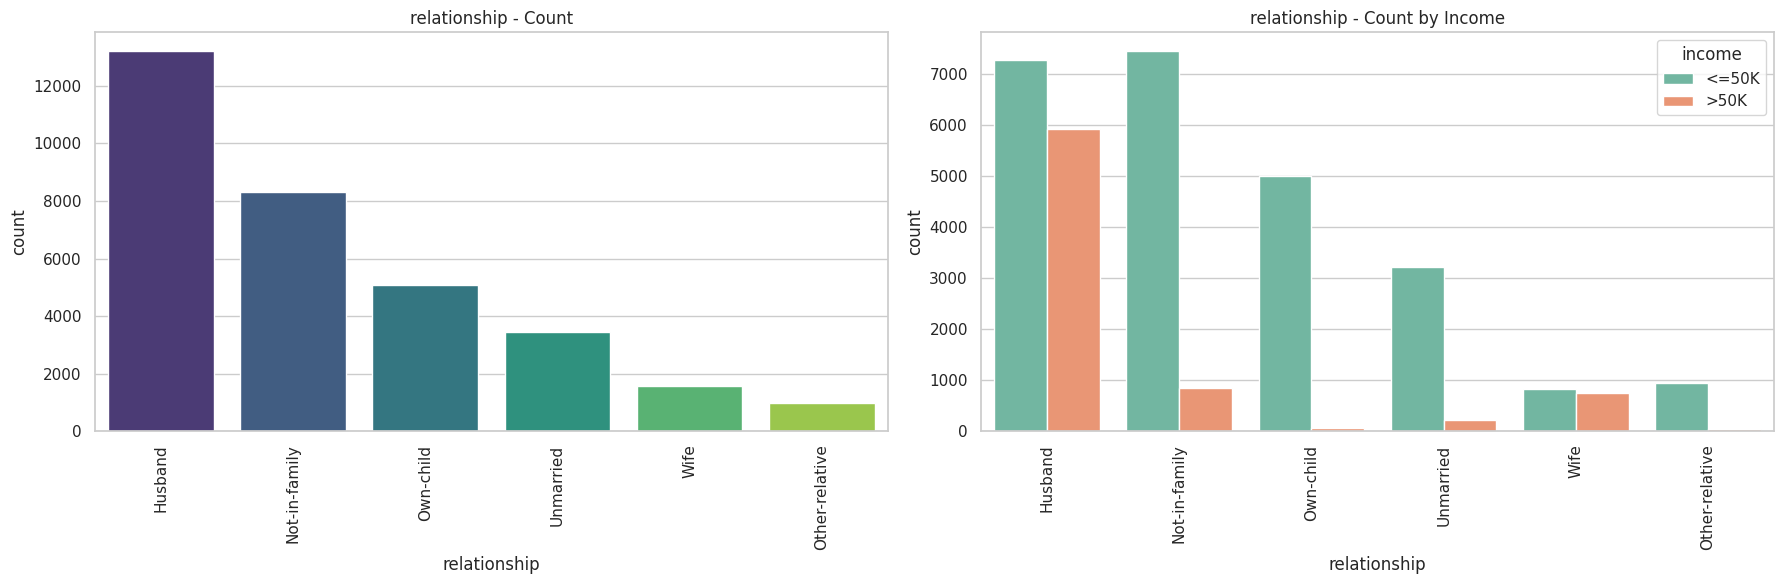

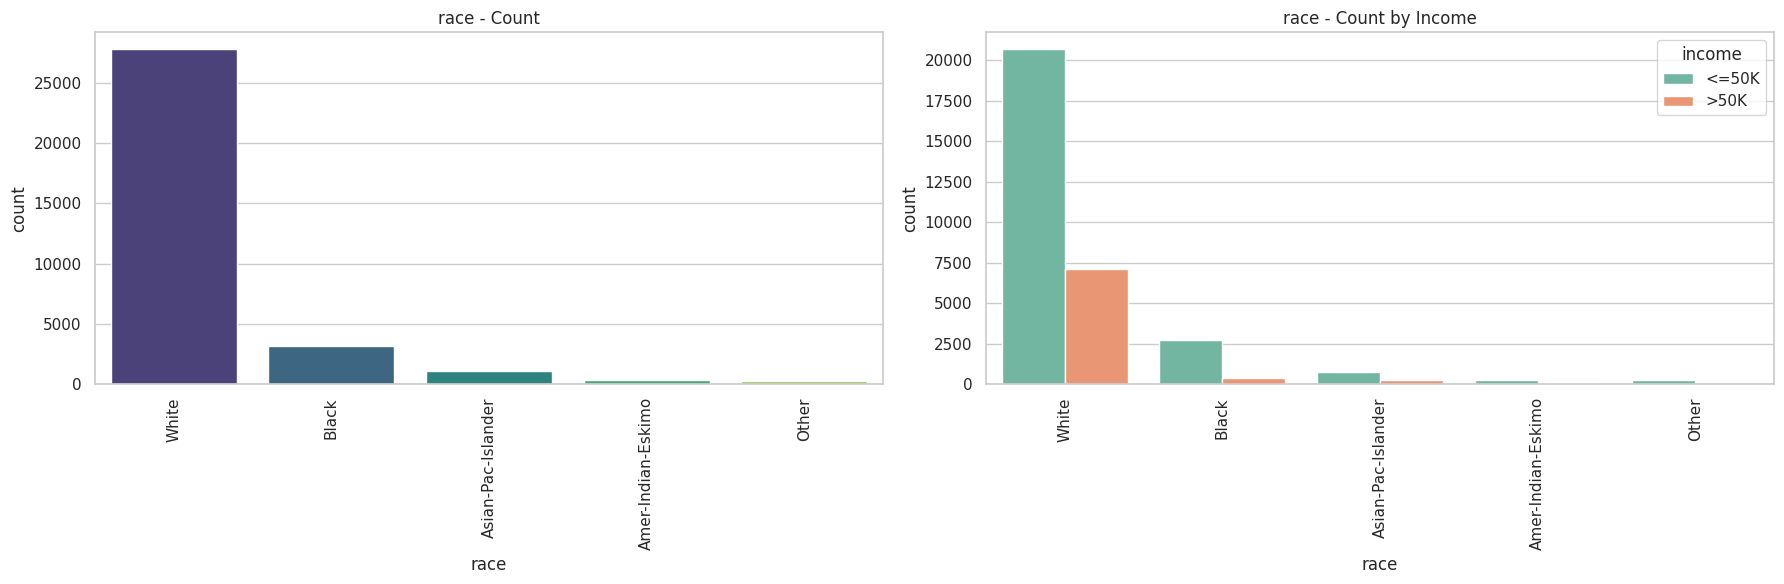

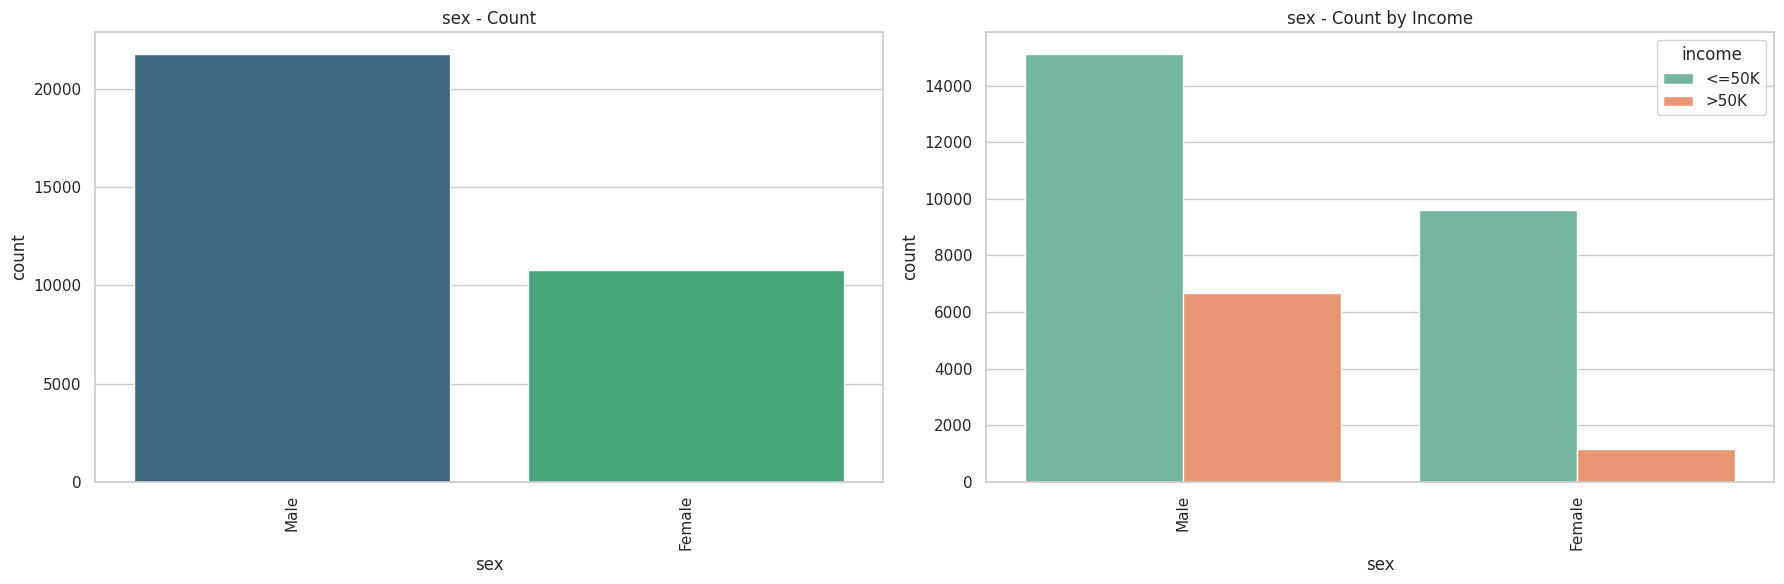

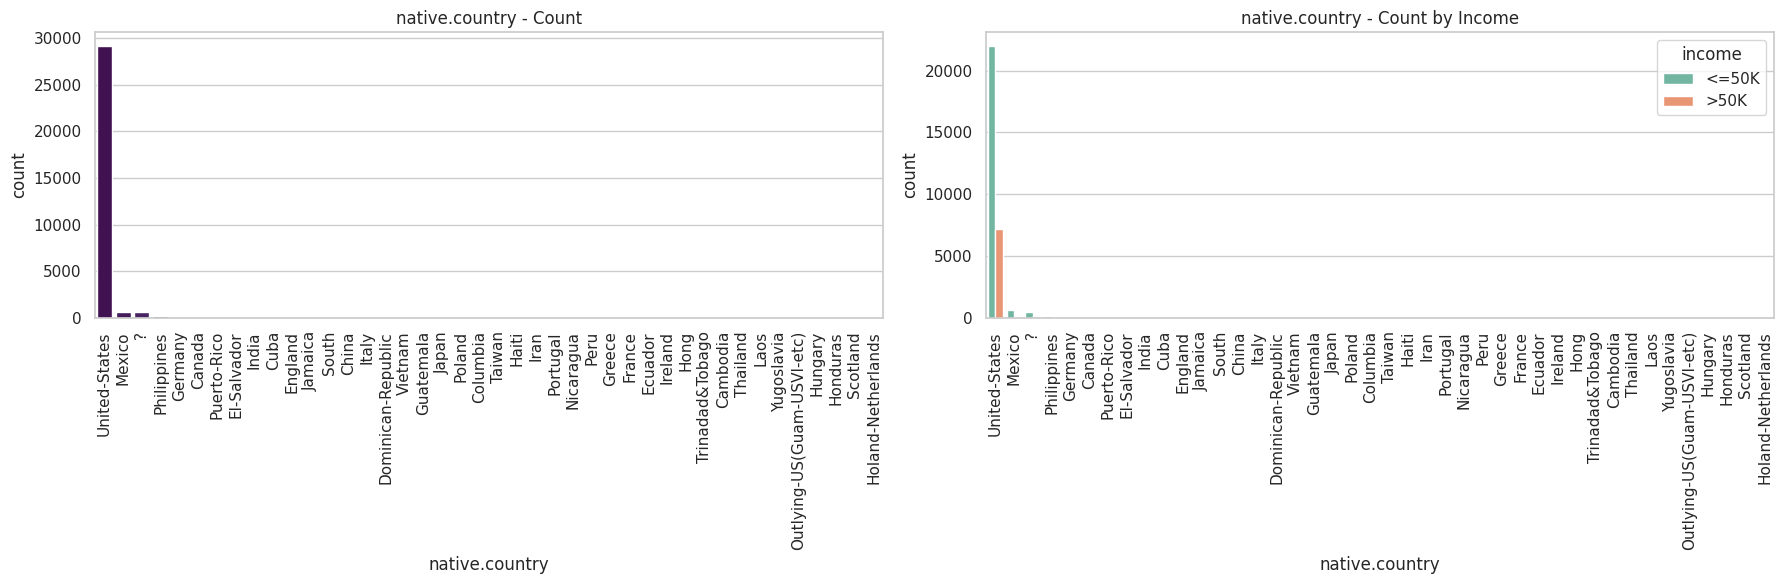

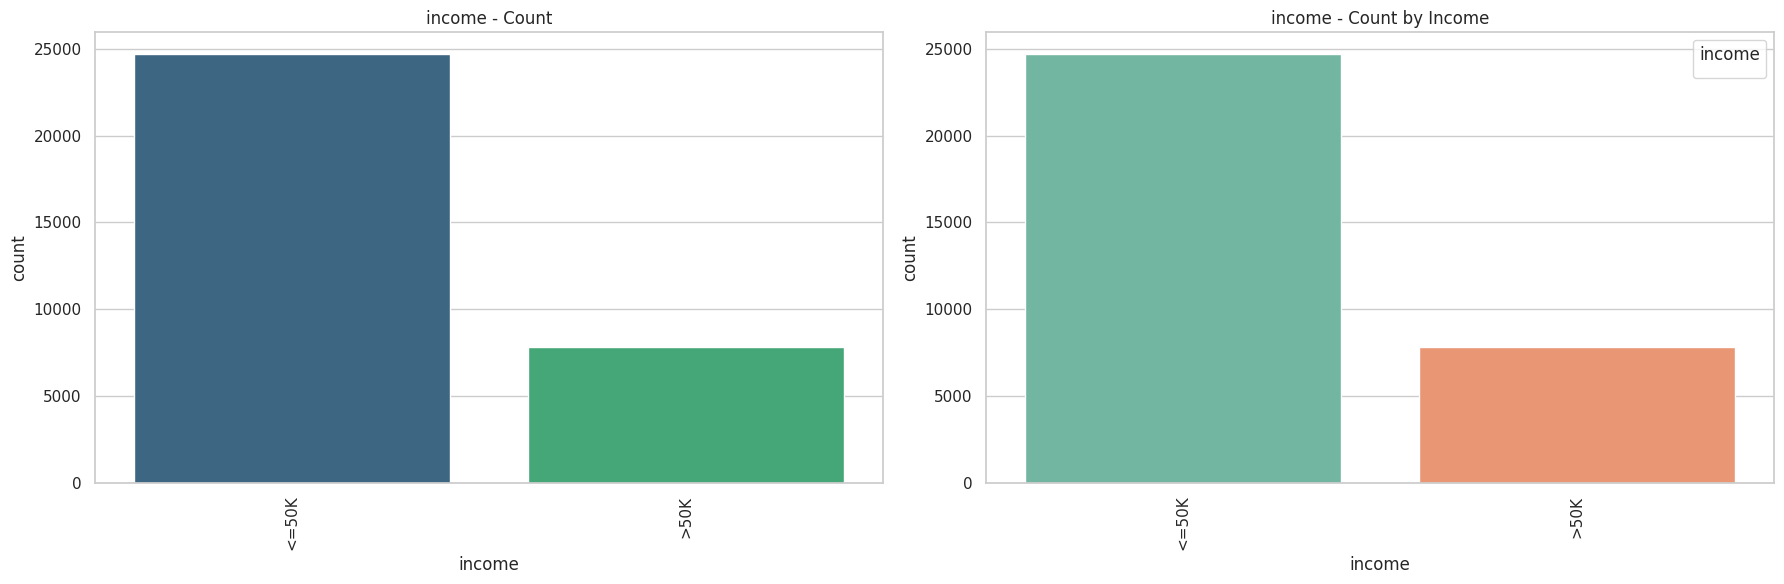

In [ ]:
sns.set(style="whitegrid")

# Get categorical columns (excluding target if desired)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Ensure target is last (income)
target = "income"

for col in categorical_cols:

    # Create figure
    plt.figure(figsize=(18, 6))

    # -------- Left Plot (Normal Count) --------
    plt.subplot(1, 2, 1)
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette="viridis"
    )

    plt.title(f"{col} - Count")
    plt.xticks(rotation=90)

    # -------- Right Plot (Hue by Income) --------
    plt.subplot(1, 2, 2)

    sns.countplot(
        data=df,
        x=col,
        hue=target,
        order=order,
        palette="Set2"
    )

    plt.title(f"{col} - Count by Income")
    plt.xticks(rotation=90)
    plt.legend(title=target)

    plt.tight_layout()
    plt.show()

<h4>Visualization of Numerical features </h4>

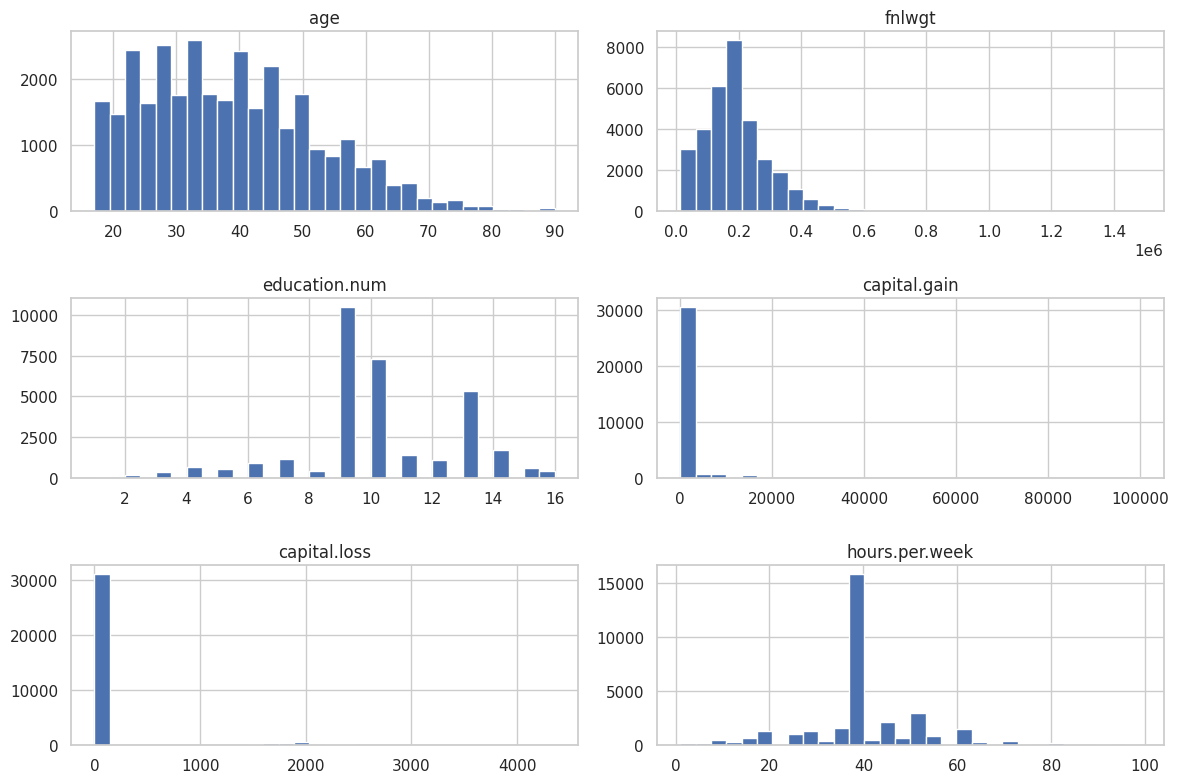

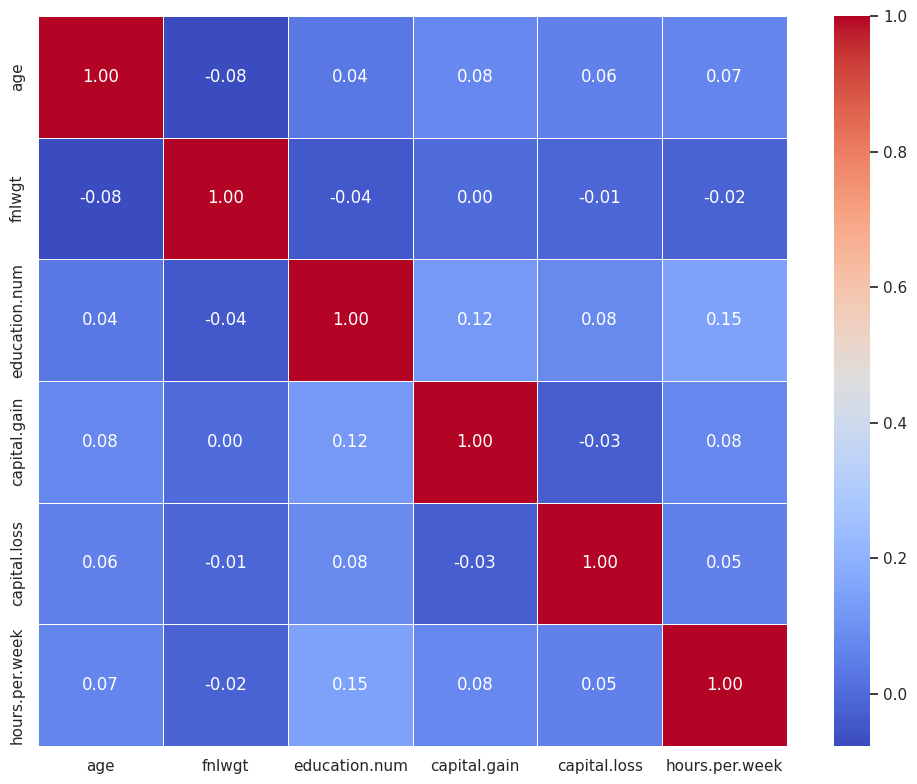

In [ ]:
# Numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# -----------------------------
# Distribution plots
# -----------------------------
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

# -----------------------------
# Correlation heatmap
# -----------------------------
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Drop redundant column before pipeline if not already dropped:
# df = df.drop(columns=["education"])

numeric_features = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
]

categorical_features = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# -----------------------
# Split
# -----------------------
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------
# Apply transformer
# -----------------------
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Convert sparse -> dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed  = X_test_transformed.toarray()

# -----------------------
# Convert target to binary
# -----------------------
y_train_encoded = (y_train == ">50K").astype(int).values
y_test_encoded  = (y_test == ">50K").astype(int).values

# -----------------------
# Convert to tensors
# -----------------------
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_transformed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_encoded, dtype=torch.long)

# -----------------------
# Create DataLoader (batch_size = 64)
# -----------------------
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, train_loader, test_loader):

    def get_metrics(loader):
        model.eval()
        all_preds, all_probs, all_labels = [], [], []

        with torch.no_grad():
            for X_batch, y_batch in loader:
                outputs = model(X_batch)
                probs = torch.sigmoid(outputs).view(-1)
                preds = (probs >= 0.5).int()

                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds)
        rec = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)
        roc = roc_auc_score(all_labels, all_probs)

        return acc, prec, rec, roc, f1

    train_metrics = get_metrics(train_loader)
    test_metrics = get_metrics(test_loader)

    metric_names = ["Accuracy", "Precision", "Recall", "ROC-AUC", "F1-Score"]

    x = np.arange(len(metric_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10,6))

    bars1 = ax.bar(x - width/2, train_metrics, width, label="Train")
    bars2 = ax.bar(x + width/2, test_metrics, width, label="Test")

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("Train vs Test Metrics")
    ax.legend()

    # ✅ Add values above bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

    return train_metrics, test_metrics

<h4>Implementing the first step of Gold Standard</h4>

<h3>Sanity Check step</h3>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Take only first 100 samples
X_small = X_train_tensor[:1]
y_small = y_train_tensor[:1].float().unsqueeze(1)

small_dataset = torch.utils.data.TensorDataset(X_small, y_small)
small_loader = torch.utils.data.DataLoader(small_dataset, batch_size=8, shuffle=True)

# Model
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

from tqdm import tqdm

epochs = 5

model.train()

for epoch in range(epochs):
    epoch_loss = 0.0

    loop = tqdm(small_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for X_batch, y_batch in loop:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {epoch_loss / len(small_loader):.4f}")

Epoch 1 Loss: 0.8512


Epoch 2 Loss: 0.8478


Epoch 3 Loss: 0.8445


Epoch 4 Loss: 0.8412


Epoch 5 Loss: 0.8378


<h4> this step is done successfully and we gurantee that model trains well</h4>

<h4>second Step training the full data on this simple model</h4>

Epoch [1/5]: 100%|██████████| 204/204 [00:01<00:00, 126.70it/s, loss=0.47]


Epoch 1 Average Loss: 0.4713


Epoch [2/5]: 100%|██████████| 204/204 [00:01<00:00, 140.89it/s, loss=0.329]


Epoch 2 Average Loss: 0.3382


Epoch [3/5]: 100%|██████████| 204/204 [00:02<00:00, 97.04it/s, loss=0.27]


Epoch 3 Average Loss: 0.3236


Epoch [4/5]: 100%|██████████| 204/204 [00:01<00:00, 109.04it/s, loss=0.467]


Epoch 4 Average Loss: 0.3183


Epoch [5/5]: 100%|██████████| 204/204 [00:01<00:00, 182.87it/s, loss=0.25]


Epoch 5 Average Loss: 0.3145


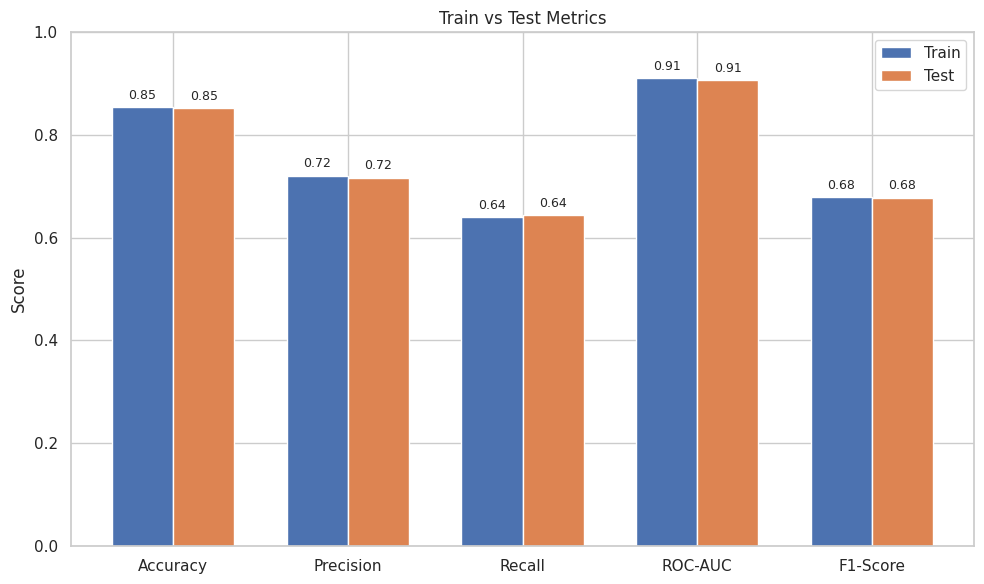

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# Model
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

# Training loop on FULL dataset
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for X_batch, y_batch in loop:
        y_batch = y_batch.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss / len(train_loader):.4f}")

# Evaluate
train_metrics, test_metrics = evaluate_model(model, train_loader, test_loader)

<h4> this steps is finished we don't see overfitting but we see lower value of recall and precision so we need to improve that </h4>

<h4> Step3 : Trying a Complex model that overfittes the training </h4>

In [ ]:
import torch
import torch.nn as nn

class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 1000),
            nn.BatchNorm1d(1000),
            nn.ReLU(),

            nn.Linear(1000, 900),
            nn.BatchNorm1d(900),
            nn.ReLU(),

            nn.Linear(900, 800),
            nn.BatchNorm1d(800),
            nn.ReLU(),

            nn.Linear(800, 700),
            nn.BatchNorm1d(700),
            nn.ReLU(),

            nn.Linear(700, 600),
            nn.BatchNorm1d(600),
            nn.ReLU(),

            nn.Linear(600, 500),
            nn.BatchNorm1d(500),
            nn.ReLU(),

            nn.Linear(500, 400),
            nn.BatchNorm1d(400),
            nn.ReLU(),

            nn.Linear(400, 350),
            nn.BatchNorm1d(350),
            nn.ReLU(),

            nn.Linear(350, 300),
            nn.BatchNorm1d(300),
            nn.ReLU(),

            nn.Linear(300, 250),
            nn.BatchNorm1d(250),
            nn.ReLU(),

            nn.Linear(250, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),

            nn.Linear(200, 150),
            nn.BatchNorm1d(150),
            nn.ReLU(),

            nn.Linear(150, 120),
            nn.BatchNorm1d(120),
            nn.ReLU(),

            nn.Linear(120, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),

            nn.Linear(100, 80),
            nn.BatchNorm1d(80),
            nn.ReLU(),

            nn.Linear(80, 60),
            nn.BatchNorm1d(60),
            nn.ReLU(),

            nn.Linear(60, 40),
            nn.BatchNorm1d(40),
            nn.ReLU(),

            nn.Linear(40, 30),
            nn.BatchNorm1d(30),
            nn.ReLU(),

            nn.Linear(30, 20),
            nn.BatchNorm1d(20),
            nn.ReLU(),

            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
epochs = 10
input_dim = X_train_tensor.shape[1]
deep_model = DeepMLP(input_dim)
optimizer = optim.Adam(deep_model.parameters(), lr=3e-4)
for epoch in range(epochs):
    deep_model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for X_batch, y_batch in loop:
        y_batch = y_batch.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = deep_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss / len(train_loader):.4f}")

Epoch [1/10]: 100%|██████████| 204/204 [00:22<00:00,  9.26it/s, loss=0.411]


Epoch 1 Average Loss: 0.4764


Epoch [2/10]: 100%|██████████| 204/204 [00:17<00:00, 11.54it/s, loss=0.387]


Epoch 2 Average Loss: 0.3542


Epoch [3/10]: 100%|██████████| 204/204 [00:18<00:00, 10.99it/s, loss=0.299]


...

Epoch 8 Average Loss: 0.2999


Epoch [9/10]: 100%|██████████| 204/204 [00:17<00:00, 11.48it/s, loss=0.283]


Epoch 9 Average Loss: 0.2980


Epoch [10/10]: 100%|██████████| 204/204 [00:19<00:00, 10.63it/s, loss=0.214]

Epoch 10 Average Loss: 0.3009


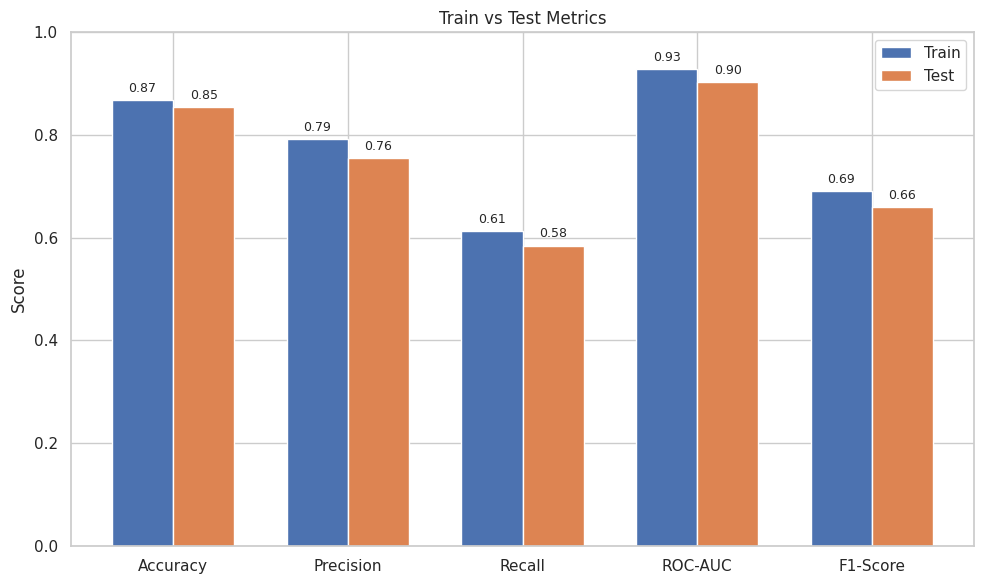

In [ ]:
train_metrics, test_metrics = evaluate_model(deep_model, train_loader, test_loader)

<h4> Step 4 : Training Data (Complex model) Regularization </h4>

<h4>Overfitting Mitigation Strategy:</h4>
<ul>
  <li>Reduce the number of epochs</li>
  <li>Apply L2 Regularization</li>
  <li>Implement a Learning Rate Schedule</li>
  <li>Reduce architecture to 10 layers (starting with 200 neurons)</li>
</ul>

In [ ]:
import torch
import torch.nn as nn

class MediumMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),

            nn.Linear(200, 180),
            nn.BatchNorm1d(180),
            nn.ReLU(),

            nn.Linear(180, 150),
            nn.BatchNorm1d(150),
            nn.ReLU(),
            nn.Linear(150, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def init_weights_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model = MediumMLP(X_train_tensor.shape[1])
model.apply(init_weights_he)

MediumMLP(
  (model): Sequential(
    (0): Linear(in_features=91, out_features=200, bias=True)
    (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=200, out_features=180, bias=True)
    (4): BatchNorm1d(180, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=180, out_features=150, bias=True)
    (7): BatchNorm1d(150, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=150, out_features=1, bias=True)
  )
)

In [ ]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-3   # ✅ L2 regularization
)

In [ ]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [ ]:
from tqdm import tqdm

epochs = 20   # reduced epochs

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for X_batch, y_batch in loop:
        y_batch = y_batch.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    scheduler.step()   # ✅ update learning rate

    print(f"Epoch {epoch+1} Avg Loss: {epoch_loss / len(train_loader):.4f}")
    print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")

Epoch [1/20]: 100%|██████████| 204/204 [00:02<00:00, 91.11it/s, loss=0.378] 


Epoch 1 Avg Loss: 0.4285
Current LR: 0.000300


Epoch [2/20]: 100%|██████████| 204/204 [00:01<00:00, 120.55it/s, loss=0.253]


Epoch 2 Avg Loss: 0.3190
Current LR: 0.000300


Epoch [3/20]: 100%|██████████| 204/204 [00:01<00:00, 122.48it/s, loss=0.262]


...

Epoch 18 Avg Loss: 0.2498
Current LR: 0.000150


Epoch [19/20]: 100%|██████████| 204/204 [00:01<00:00, 117.96it/s, loss=0.354]


Epoch 19 Avg Loss: 0.2471
Current LR: 0.000150


Epoch [20/20]: 100%|██████████| 204/204 [00:01<00:00, 121.90it/s, loss=0.263]

Epoch 20 Avg Loss: 0.2452
Current LR: 0.000075


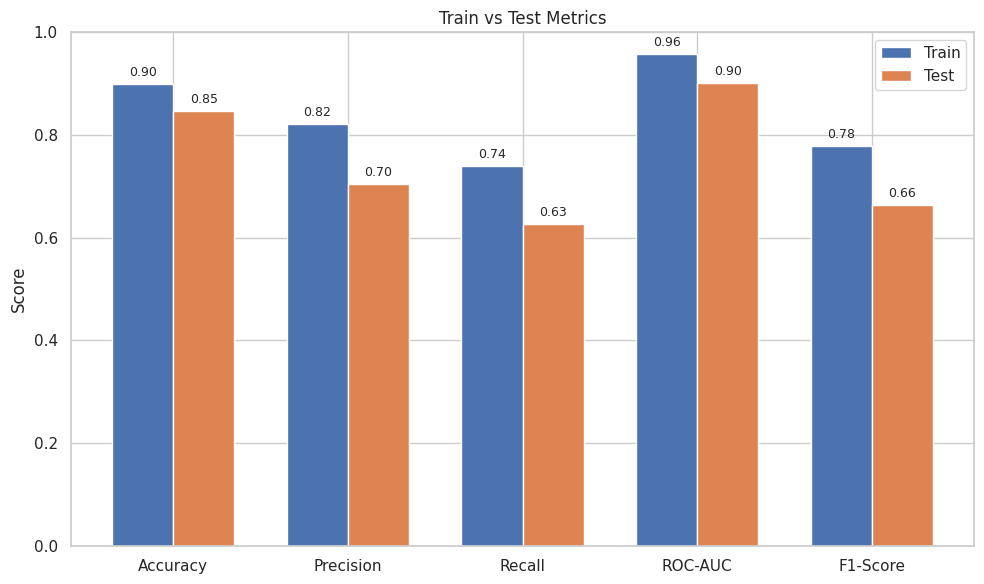

In [ ]:
train_metrics, test_metrics = evaluate_model(model, train_loader, test_loader)

<h4>The recall in this model after we do some improvement became much better although the accuracy in training and test accuracy remains the same
but the precision improves in training data but become lower in test data.</h4>